In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

mortality increase due to covid: 1.444912703190849
0.9917293912401173
0.0080675261314983
-0.0080675261314983
Loss of:  0.0
deaths 0.008270608759882725


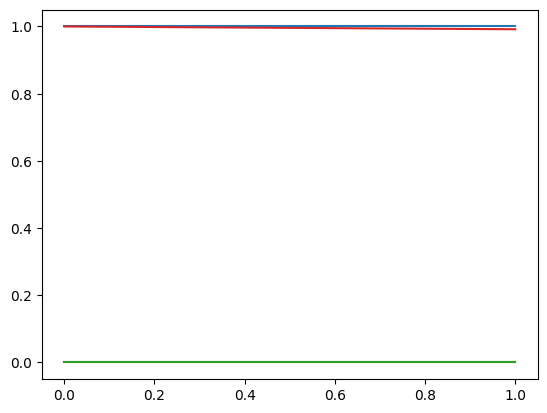

In [19]:
mu = 830.5/100000 #base death rate
DB = 1
P = -mu*DB
# mu * (1 + mort_factor) = case fatality rate + general mortality
mort_factor =  (0.012+ mu)/mu -1  #increase due to covid infection
print("mortality increase due to covid:",mort_factor)
delta = 0.05 # force of interest
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([1,0.00,0,1,0]) # S,I,R,Alive, dead
R0 = 3.99 #estimate of R0 in Canada at initial outbreak
def ddt(u,t):
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+mort_factor*u[1])*u[3]
    dudt[4] = mu*(1+mort_factor*u[1])*u[3]
    return dudt
    

t = np.linspace(0,1,1000)
y0 = spi.odeint(ddt, ic, t)

alive_pandemic = y0[:,3]

plt.plot(t, y0[:,0:4])
print(y0[999,3])
tpx = y0[:,3]
mu_xt = mu*(1+mort_factor*y0[:,1])
discount = np.exp(-delta *t)
integrand_ben = DB* tpx * mu_xt *discount
integrand_prem = P * tpx * discount
EPV_ben = spi.trapezoid(integrand_ben,t)
EPV_prem = spi.trapezoid(integrand_prem,t)
print(EPV_ben)
print(EPV_prem)
print("Loss of: ", EPV_ben + EPV_prem)
print("deaths", 1- y0[999,3])